## Expert Knowledge Worker

### A question answering agent that is an expert knowledge worker
### To be used by employees of Insurellm, an Insurance Tech company
### The agent needs to be accurate and the solution should be low cost.

This project will use RAG (Retrieval Augmented Generation) to ensure our question/answering assistant has high accuracy.

This first implementation will use a simple, brute-force type of RAG..

In [1]:
# imports

import os
import glob
from dotenv import load_dotenv
import gradio as gr

In [2]:
# imports for langchain, plotly and Chroma

from langchain.document_loaders import DirectoryLoader, TextLoader
from langchain.text_splitter import CharacterTextSplitter
from langchain.schema import Document
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_chroma import Chroma
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import numpy as np
import plotly.graph_objects as go
from langchain.memory import ConversationBufferMemory
from langchain.chains import ConversationalRetrievalChain
from langchain.embeddings import HuggingFaceEmbeddings

Matplotlib is building the font cache; this may take a moment.


In [3]:
# price is a factor for our company, so we're going to use a low cost model

MODEL = "gpt-4o-mini"
db_name = "vector_db"

In [4]:
# Load environment variables in a file called .env

load_dotenv(override=True)
os.environ['OPENAI_API_KEY'] = os.getenv('OPENAI_API_KEY', 'your-key-if-not-using-env')

In [5]:
# Read in documents using LangChain's loaders
# Take everything in all the sub-folders of our knowledgebase

folders = glob.glob("knowledge-base/*")

def add_metadata(doc, doc_type):
    doc.metadata["doc_type"] = doc_type
    return doc

# With thanks to CG and Jon R, students on the course, for this fix needed for some users 
text_loader_kwargs = {'encoding': 'utf-8'}
# If that doesn't work, some Windows users might need to uncomment the next line instead
# text_loader_kwargs={'autodetect_encoding': True}

documents = []
for folder in folders:
    doc_type = os.path.basename(folder)
    loader = DirectoryLoader(folder, glob="**/*.md", loader_cls=TextLoader, loader_kwargs=text_loader_kwargs)
    folder_docs = loader.load()
    documents.extend([add_metadata(doc, doc_type) for doc in folder_docs])

text_splitter = CharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
chunks = text_splitter.split_documents(documents)

print(f"Total number of chunks: {len(chunks)}")
print(f"Document types found: {set(doc.metadata['doc_type'] for doc in documents)}")

Created a chunk of size 1088, which is longer than the specified 1000


Total number of chunks: 123
Document types found: {'contracts', 'products', 'employees', 'company'}


## A sidenote on Embeddings, and "Auto-Encoding LLMs"

We will be mapping each chunk of text into a Vector that represents the meaning of the text, known as an embedding.

OpenAI offers a model to do this, which we will use by calling their API with some LangChain code.

This model is an example of an "Auto-Encoding LLM" which generates an output given a complete input.
It's different to all the other LLMs we've discussed today, which are known as "Auto-Regressive LLMs", and generate future tokens based only on past context.

Another example of an Auto-Encoding LLMs is BERT from Google. In addition to embedding, Auto-encoding LLMs are often used for classification.

### Sidenote

In week 8 we will return to RAG and vector embeddings, and we will use an open-source vector encoder so that the data never leaves our computer - that's an important consideration when building enterprise systems and the data needs to remain internal.

In [6]:
# Put the chunks of data into a Vector Store that associates a Vector Embedding with each chunk
# Chroma is a popular open source Vector Database based on SQLLite

embeddings = OpenAIEmbeddings()

# If you would rather use the free Vector Embeddings from HuggingFace sentence-transformers
# Then replace embeddings = OpenAIEmbeddings()
# with:
# from langchain.embeddings import HuggingFaceEmbeddings
# embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")

# Delete if already exists

if os.path.exists(db_name):
    Chroma(persist_directory=db_name, embedding_function=embeddings).delete_collection()

# Create vectorstore

vectorstore = Chroma.from_documents(documents=chunks, embedding=embeddings, persist_directory=db_name)
print(f"Vectorstore created with {vectorstore._collection.count()} documents")

Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given
Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given
Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given
Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


Vectorstore created with 123 documents


In [7]:
# Let's investigate the vectors

collection = vectorstore._collection
count = collection.count()

sample_embedding = collection.get(limit=1, include=["embeddings"])["embeddings"][0]
dimensions = len(sample_embedding)
print(f"There are {count:,} vectors with {dimensions:,} dimensions in the vector store")

Failed to send telemetry event CollectionGetEvent: capture() takes 1 positional argument but 3 were given


There are 123 vectors with 1,536 dimensions in the vector store


## Visualizing the Vector Store

Let's take a minute to look at the documents and their embedding vectors to see what's going on.

In [ ]:
# Prework (with thanks to Jon R for identifying and fixing a bug in this!)

result = collection.get(include=['embeddings', 'documents', 'metadatas'])
vectors = np.array(result['embeddings'])
documents = result['documents']
metadatas = result['metadatas']
doc_types = [metadata['doc_type'] for metadata in metadatas]
colors = [['blue', 'green', 'red', 'orange'][['products', 'employees', 'contracts', 'company'].index(t)] for t in doc_types]

In [ ]:
# We humans find it easier to visalize things in 2D!
# Reduce the dimensionality of the vectors to 2D using t-SNE
# (t-distributed stochastic neighbor embedding)

tsne = TSNE(n_components=2, random_state=42)
reduced_vectors = tsne.fit_transform(vectors)

# Create the 2D scatter plot
fig = go.Figure(data=[go.Scatter(
    x=reduced_vectors[:, 0],
    y=reduced_vectors[:, 1],
    mode='markers',
    marker=dict(size=5, color=colors, opacity=0.8),
    text=[f"Type: {t}<br>Text: {d[:100]}..." for t, d in zip(doc_types, documents)],
    hoverinfo='text'
)])

fig.update_layout(
    title='2D Chroma Vector Store Visualization',
    scene=dict(xaxis_title='x',yaxis_title='y'),
    width=800,
    height=600,
    margin=dict(r=20, b=10, l=10, t=40)
)

fig.show()

In [ ]:
# Let's try 3D!

tsne = TSNE(n_components=3, random_state=42)
reduced_vectors = tsne.fit_transform(vectors)

# Create the 3D scatter plot
fig = go.Figure(data=[go.Scatter3d(
    x=reduced_vectors[:, 0],
    y=reduced_vectors[:, 1],
    z=reduced_vectors[:, 2],
    mode='markers',
    marker=dict(size=5, color=colors, opacity=0.8),
    text=[f"Type: {t}<br>Text: {d[:100]}..." for t, d in zip(doc_types, documents)],
    hoverinfo='text'
)])

fig.update_layout(
    title='3D Chroma Vector Store Visualization',
    scene=dict(xaxis_title='x', yaxis_title='y', zaxis_title='z'),
    width=900,
    height=700,
    margin=dict(r=20, b=10, l=10, t=40)
)

fig.show()

## Time to use LangChain to bring it all together

In [8]:
# create a new Chat with OpenAI
llm = ChatOpenAI(temperature=0.7, model_name=MODEL)

# Alternative - if you'd like to use Ollama locally, uncomment this line instead
# llm = ChatOpenAI(temperature=0.7, model_name='llama3.2', base_url='http://localhost:11434/v1', api_key='ollama')

# set up the conversation memory for the chat
memory = ConversationBufferMemory(memory_key='chat_history', return_messages=True)

# the retriever is an abstraction over the VectorStore that will be used during RAG
retriever = vectorstore.as_retriever()

# putting it together: set up the conversation chain with the GPT 3.5 LLM, the vector store and memory
conversation_chain = ConversationalRetrievalChain.from_llm(llm=llm, retriever=retriever, memory=memory)

/var/folders/lp/c6c41311535f4lt5y8yk_kfw0000gn/T/ipykernel_12645/1174663558.py:8: LangChainDeprecationWarning: Please see the migration guide at: https://python.langchain.com/docs/versions/migrating_memory/
  memory = ConversationBufferMemory(memory_key='chat_history', return_messages=True)


In [9]:
# Let's try a simple question

query = "Please explain what Insurellm is in a couple of sentences"
result = conversation_chain.invoke({"question": query})
print(result["answer"])

Failed to send telemetry event CollectionQueryEvent: capture() takes 1 positional argument but 3 were given


Insurellm is an innovative insurance tech startup founded in 2015 by Avery Lancaster, designed to disrupt the insurance industry with its software products. It offers four main products: Carllm for auto insurance, Homellm for home insurance, Rellm for the reinsurance sector, and Marketllm, a marketplace connecting consumers with insurance providers, serving over 300 clients worldwide.


In [10]:
# set up a new conversation memory for the chat
memory = ConversationBufferMemory(memory_key='chat_history', return_messages=True)

# putting it together: set up the conversation chain with the GPT 4o-mini LLM, the vector store and memory
conversation_chain = ConversationalRetrievalChain.from_llm(llm=llm, retriever=retriever, memory=memory)

## Now we will bring this up in Gradio using the Chat interface -

A quick and easy way to prototype a chat with an LLM

In [11]:
# Wrapping that in a function

def chat(question, history):
    result = conversation_chain.invoke({"question": question})
    return result["answer"]

In [13]:
# And in Gradio:

view = gr.ChatInterface(chat, type="messages").launch(inbrowser=True)

* Running on local URL:  http://127.0.0.1:7861
* To create a public link, set `share=True` in `launch()`.


**Lets see the Problem here -**
If we go to the empoyees section of our InsuranLLM company knowledge base, we have the employee Maxine Thompson with below data.

```text
   She was recognized as Insurellm Innovator of the year in 2023, receiving the prestigious IIOTY 2023 award.    
```
When we try to ask the question on this employee to our chatAgent , we see below -
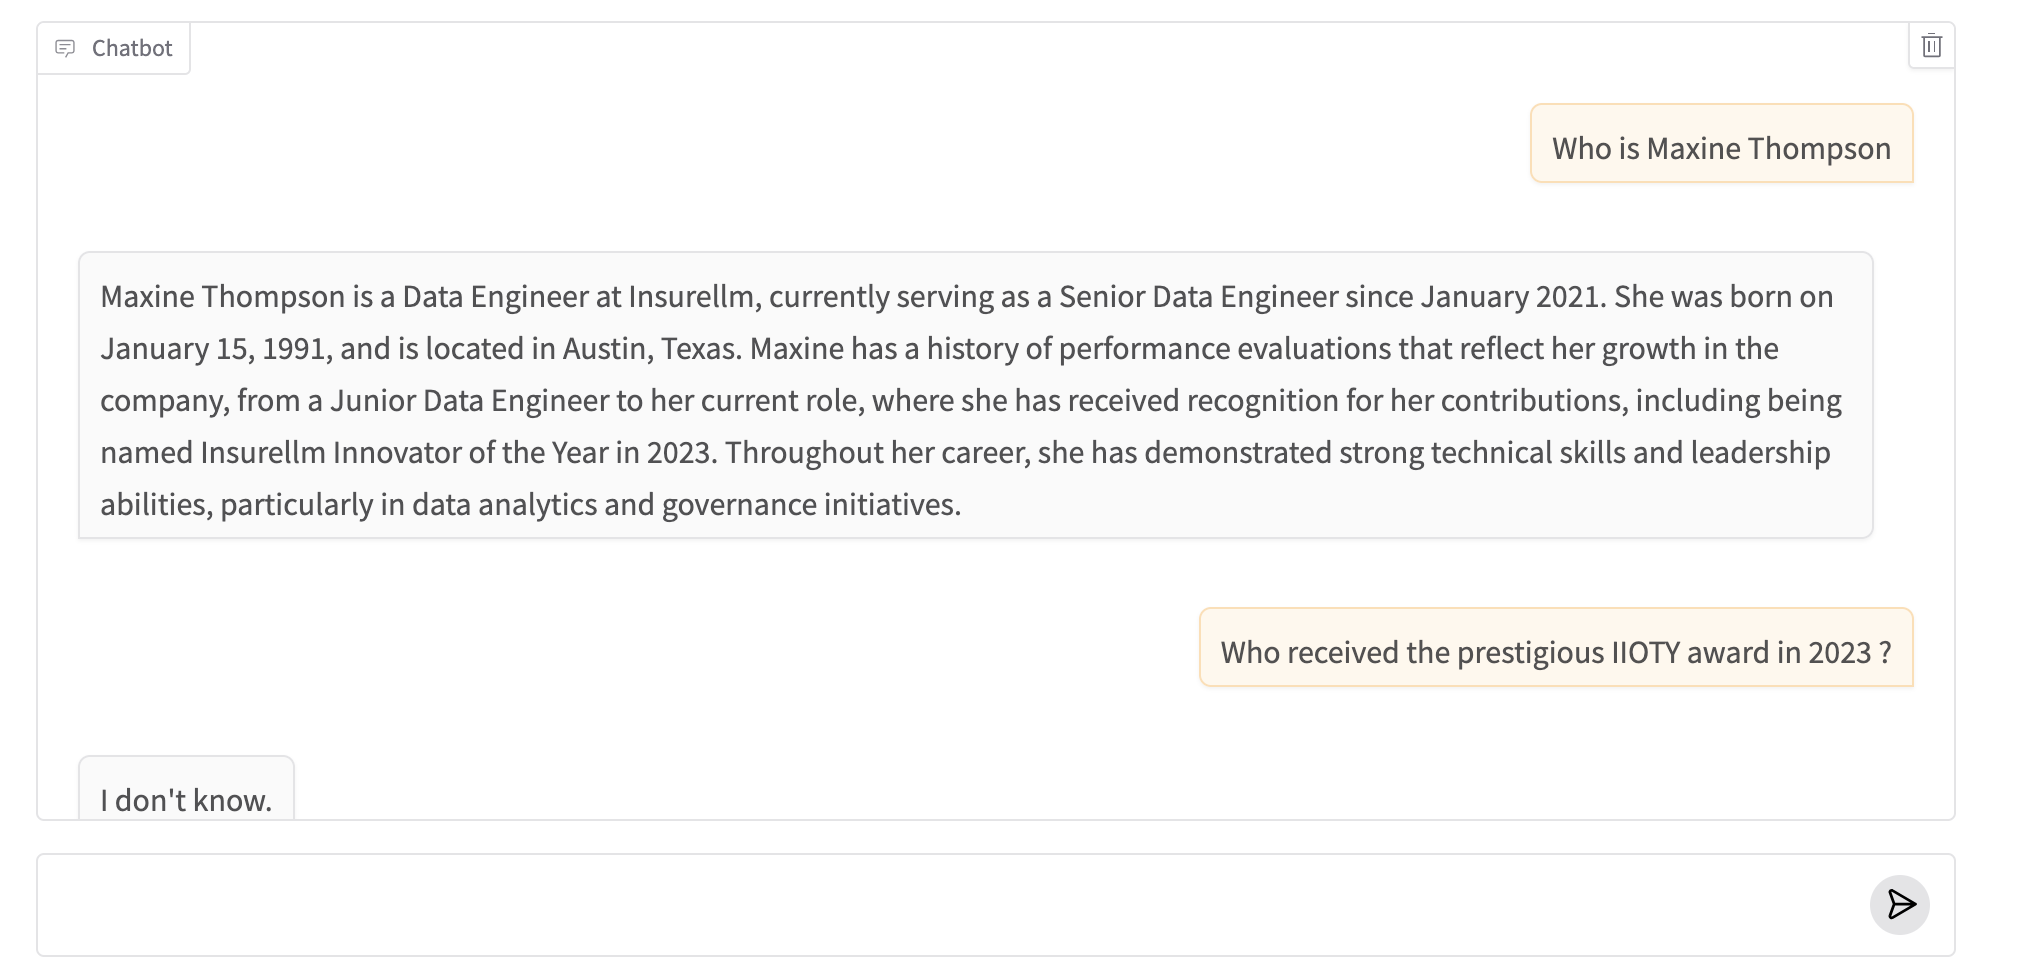

So lets see How to diagonise this problem using callbacks.


# Using Callbacks to See what is going on with Langchain behind the scenes

In [15]:
# Let's investigate what gets sent behind the scenes

from langchain_core.callbacks import StdOutCallbackHandler

llm = ChatOpenAI(temperature=0.7, model_name=MODEL)

memory = ConversationBufferMemory(memory_key='chat_history', return_messages=True)

retriever = vectorstore.as_retriever()

conversation_chain = ConversationalRetrievalChain.from_llm(llm=llm, retriever=retriever, memory=memory, callbacks=[StdOutCallbackHandler()])

query = "Who received the prestigious IIOTY award in 2023?"
result = conversation_chain.invoke({"question": query})
answer = result["answer"]
print("\nAnswer:", answer)



> Entering new ConversationalRetrievalChain chain...


> Entering new StuffDocumentsChain chain...


> Entering new LLMChain chain...
Prompt after formatting:
System: Use the following pieces of context to answer the user's question. 
If you don't know the answer, just say that you don't know, don't try to make up an answer.
----------------
- **2022**: **Satisfactory**  
  Avery focused on rebuilding team dynamics and addressing employee concerns, leading to overall improvement despite a saturated market.  

- **2023**: **Exceeds Expectations**  
  Market leadership was regained with innovative approaches to personalized insurance solutions. Avery is now recognized in industry publications as a leading voice in Insurance Tech innovation.

## Annual Performance History
- **2020:**  
  - Completed onboarding successfully.  
  - Met expectations in delivering project milestones.  
  - Received positive feedback from the team leads.

- **2021:**  
  - Achieved a 95% success rate in proj

#### Above code snippet has the below code -
**1. We create the LLM**<br>
**2. We create the memory**<br>
**3. We cerate the retriever using chroma as the vector database**<br>
**4. We then create the conversation chain**<br>
**5. Finally we invoke the chain on the prompt we used earlier**<br>


### As we can see here in our conversational chain we are passing a list of Callbacks , even though we have only one callback here , we can pass a list of callbacks if needed

**This is is a predefined callback that repeatedly writes the logs to the console or stdout**

Once we run it we can see that the entire stack trace of the call is written tot he console.
And **We are able to see the actual prompt that was passed to the LLM**

**Note - There are a bunch of other callbacks that we can use to see the trace in more detail in each of the steps of the langchain execution.**

And Below is our complete prompt that Langchain is passing-
```
Entering new LLMChain chain...
Prompt after formatting:
System: Use the following pieces of context to answer the user's question. 
If you don't know the answer, just say that you don't know, don't try to make up an answer.
----------------
- **2022**: **Satisfactory**  
  Avery focused on rebuilding team dynamics and addressing employee concerns, leading to overall improvement despite a saturated market.  

- **2023**: **Exceeds Expectations**  
  Market leadership was regained with innovative approaches to personalized insurance solutions. Avery is now recognized in industry publications as a leading voice in Insurance Tech innovation.

## Annual Performance History
- **2020:**  
  - Completed onboarding successfully.  
  - Met expectations in delivering project milestones.  
  - Received positive feedback from the team leads.

- **2021:**  
  - Achieved a 95% success rate in project delivery timelines.  
  - Awarded "Rising Star" at the annual company gala for outstanding contributions.  

- **2022:**  
  - Exceeded goals by optimizing existing backend code, improving system performance by 25%.  
  - Conducted training sessions for junior developers, fostering knowledge sharing.  

- **2023:**  
  - Led a major overhaul of the API internal architecture, enhancing security protocols.  
  - Contributed to the company’s transition to a cloud-based infrastructure.  
  - Received an overall performance rating of 4.8/5.

## Annual Performance History
- **2018**: **3/5** - Adaptable team player but still learning to take initiative.
- **2019**: **4/5** - Demonstrated strong problem-solving skills, outstanding contribution on the claims project.
- **2020**: **2/5** - Struggled with time management; fell behind on deadlines during a high-traffic release period.
- **2021**: **4/5** - Made a significant turnaround with organized work habits and successful project management.
- **2022**: **5/5** - Exceptional performance during the "Innovate" initiative, showcasing leadership and creativity.
- **2023**: **3/5** - Maintaining steady work; expectations for innovation not fully met, leading to discussions about goals.

## Annual Performance History
- **2023:** Rating: 4.5/5  
  *Samuel exceeded expectations, successfully leading a cross-departmental project on AI-driven underwriting processes.*

- **2022:** Rating: 3.0/5  
  *Some challenges in meeting deadlines and collaboration with the engineering team. Received constructive feedback and participated in a team communication workshop.*

- **2021:** Rating: 4.0/5  
  *There was notable improvement in performance. Worked to enhance model accuracy, leading to improved risk assessment outcomes for B2C customers.*

- **2020:** Rating: 3.5/5  
  *Exhibited a solid performance during the initial year as a Senior Data Scientist but had struggles adapting to new leadership expectations.*

## Compensation History
- **2023:** Base Salary: $115,000 + Bonus: $15,000  
  *Annual bonus based on successful project completions and performance metrics.*
Human: Who received the prestigious IIOTY award in 2023?
```

**The structure of the Prompt that has been passed is -** <br>
**1. First the system prompt.** <br>
**2. Then the context - multiple chunks of data passed based on the similarity search that was done with the question and the data in the vector store.** <br>
**3. The actual user prompt or question.** <br>

**As we can see here the chunks that are being passed with the prompt is not actually the correct chunk that contains the data of who won the IIOTY award in 2023 and therefore as the system prompt says that if you do not knoew the answer simply say do not know, therefore the LLM does the same.**



## So then what can we do when the correct chunks are not being passed ?
Note - It is a very common problem.

There are a couple of things we can do -
1. Look at our chunking stratergy . How we are dividing the text into chunks. One way to do this would be instead of chunking we can send entire documents in the vector database and then we can look for the document in the vectordatabase that has the vectors similar to the vector of the question being asked.
2. Or We can also have more fine grained or smaller chunks and test out various combination of the overlap between the chunks.(try increasing/decreasing) to see if it works.
3. We can also configure the amount or number of chunks that gets sent. By default here three chunks are getting sent , but we can change that.
       This can be configured when we are defining the retriever.
   
   **While getting the retriever we can see how many chunks gets passed in. Below we have passed 25 chunks .**

**Note - As a general rule of thumb , It is always better to provide the LLMs with more context. So it is advisable to have more chunks sent in to the prompt . Except for in few cases. Like in case of newer reasoning models of OpenAI where the prompts are looked at much more detail and some analysis is done behind the scenes with chain of thoughts.
For this models provinding too much data can slow down the model**



In [16]:
# create a new Chat with OpenAI
llm = ChatOpenAI(temperature=0.7, model_name=MODEL)

# set up the conversation memory for the chat
memory = ConversationBufferMemory(memory_key='chat_history', return_messages=True)

# the retriever is an abstraction over the VectorStore that will be used during RAG; k is how many chunks to use
retriever = vectorstore.as_retriever(search_kwargs={"k": 25})
print(retriever)

# putting it together: set up the conversation chain with the GPT 3.5 LLM, the vector store and memory
conversation_chain = ConversationalRetrievalChain.from_llm(llm=llm, retriever=retriever, memory=memory)

tags=['Chroma', 'OpenAIEmbeddings'] vectorstore=<langchain_chroma.vectorstores.Chroma object at 0x3541ef810> search_kwargs={'k': 25}


In [17]:
def chat(question, history):
    result = conversation_chain.invoke({"question": question})
    return result["answer"]

In [18]:
view = gr.ChatInterface(chat, type="messages").launch(inbrowser=True)

* Running on local URL:  http://127.0.0.1:7862
* To create a public link, set `share=True` in `launch()`.


## So with this now the correct result is being returned-
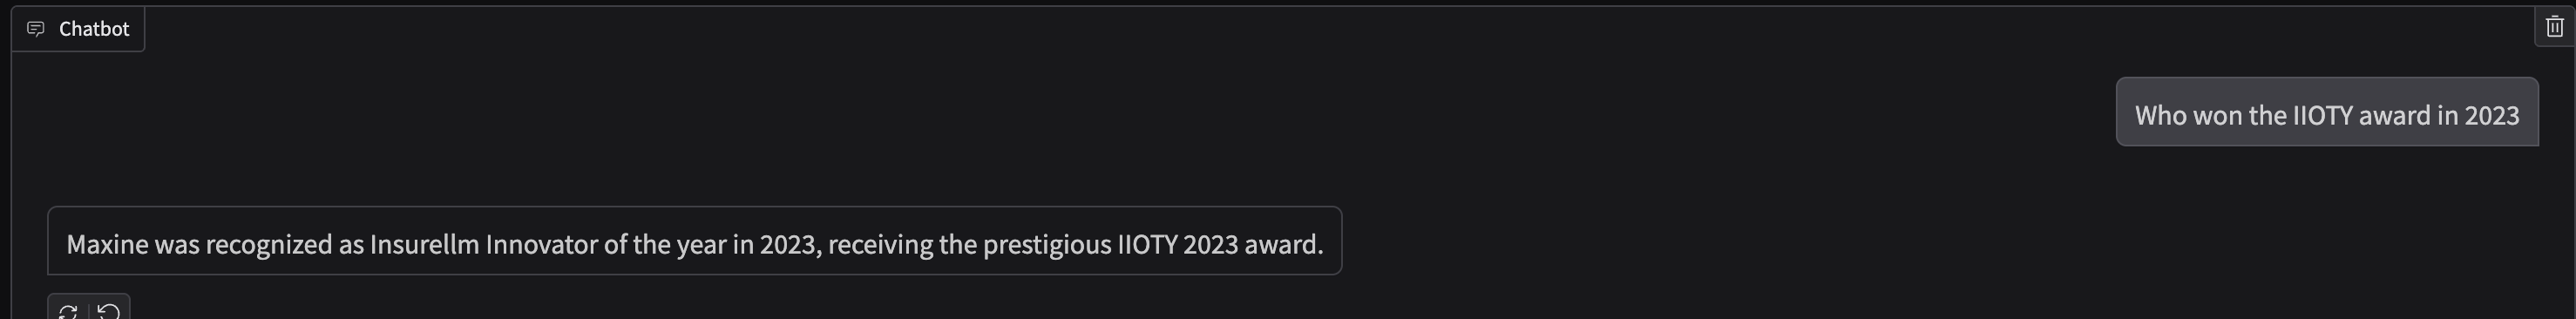

# Exercises

Try applying this to your own folder of data, so that you create a personal knowledge worker, an expert on your own information!
Add some data into the knowledgebase and ask question based on that
Try chunking / passing entire document as the embedding and see if there is any difference in the result.